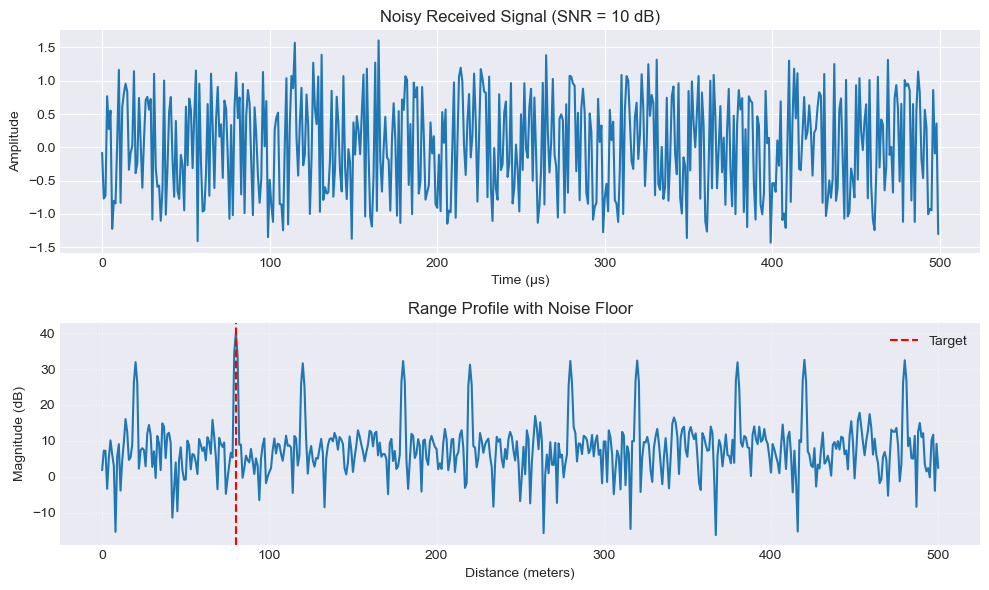

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Radar & Simulation Parameters ---
c = 3e8
fs = 1e6
T_sweep = 1e-3
BW = 150e6
fc = 77e9
slope = BW / T_sweep
target_range = 80.0
snr_db = 10  # Target Signal-to-Noise Ratio in dB

# --- 2. Signal Generation ---
t = np.linspace(0, T_sweep, int(fs * T_sweep), endpoint=False)
tau = 2 * target_range / c

# Transmitted Signal
tx_signal = np.cos(2 * np.pi * (fc * t + 0.5 * slope * t**2))

# Received Signal (Delayed)
rx_t = t - tau
rx_signal = np.cos(2 * np.pi * (fc * rx_t + 0.5 * slope * rx_t**2))

# --- 3. Adding Noise ---
# Calculate signal power and convert SNR from dB to linear
sig_power = np.mean(rx_signal**2)
snr_linear = 10**(snr_db / 10)

# Calculate required noise power (noise_power = signal_power / SNR)
noise_power = sig_power / snr_linear
noise = np.random.normal(0, np.sqrt(noise_power), len(rx_signal))

# Add noise to the received signal
rx_signal_noisy = rx_signal + noise

# --- 4. Processing ---
# Mix Tx with the NOISY Rx signal
beat_signal = tx_signal * rx_signal_noisy

# FFT Processing
n_fft = len(beat_signal)
f_axis = np.fft.rfftfreq(n_fft, 1/fs)
# Using a window function (like Hanning) helps suppress sidelobes in noisy data
window = np.hanning(len(beat_signal))
fft_magnitude = np.abs(np.fft.rfft(beat_signal * window))

range_axis = (f_axis * c * T_sweep) / (2 * BW)

# --- 5. Visualization ---
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:500] * 1e6, rx_signal_noisy[:500])
plt.title(f"Noisy Received Signal (SNR = {snr_db} dB)")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(range_axis, 20 * np.log10(fft_magnitude))
plt.title("Range Profile with Noise Floor")
plt.xlabel("Distance (meters)")
plt.ylabel("Magnitude (dB)")
plt.axvline(x=target_range, color='r', linestyle='--', label='Target')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()